In [16]:
from ResNet_18 import ResNet18

In [17]:
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader, TensorDataset

In [18]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

 

In [19]:
model = ResNet18(num_classes=10).to(device=device)
model.load_state_dict(torch.load("resnet18_eurosat.pth", weights_only=True), )


<All keys matched successfully>

In [20]:
X_test = torch.load("X_test.pt", weights_only=False)
Y_test = torch.load("Y_test.pt", weights_only=False)



In [21]:
X_test[0].shape

(13, 64, 64)

In [22]:
X_test = torch.stack([torch.tensor(img, dtype=torch.float32) for img in X_test ])

In [23]:
Test_dataset = TensorDataset(X_test, Y_test)
Test_loader = DataLoader(Test_dataset,  batch_size=64)

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

Mean = [
    0.13543268, 0.11175188, 0.10418837, 0.09467538, 0.11996479,
    0.20028183, 0.23731175, 0.23004931, 0.07332496, 0.0012104,
    0.18213873, 0.11190669, 0.25987505
]

Std = [
    0.02457886, 0.03333259, 0.0395221, 0.05942802, 0.05672322,
    0.08590868, 0.10834781, 0.11147044, 0.04039885, 0.00047205,
    0.10015353, 0.07607304, 0.12276264
]

Mean = torch.tensor(Mean, dtype=torch.float32)
Std = torch.tensor(Std, dtype=torch.float32)

classes = [
    'AnnualCrop',
    'Forest',
    'HerbaceousVegetation',
    'Highway',
    'Industrial',
    'Pasture',
    'PermanentCrop',
    'Residential',
    'River',
    'SeaLake'
]


def predict(i):

    img = X_test[i]

    img_view = img * Std[:, None, None] + Mean[:, None, None]

    rgb = img_view[[3, 2, 1]]
    rgb = rgb.permute(1, 2, 0)

    rgb = torch.clamp(rgb, 0, 1)

    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

    img = img.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(img)
        prob = torch.softmax(output, dim=1)

    predicted_idx = prob.argmax(dim=1).item()
    actual_idx = Y_test[i].item()

    print("Actual:", classes[actual_idx])
    print("Predicted:", classes[predicted_idx])
    print("Probability:", prob[0, predicted_idx].item())

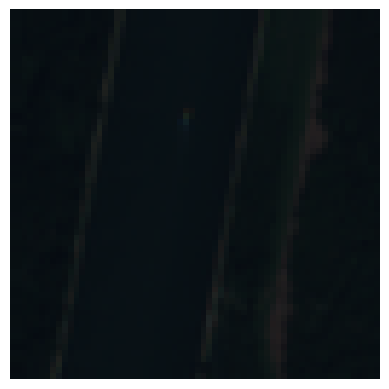

Actual: River
Predicted: Industrial
Probability: 0.10761038213968277


In [25]:
predict(1001)

In [26]:
def predict_multiple(indices, delay=5):

    model.eval()

    for i in indices:

        img = X_test[i]

        img_view = img * Std[:, None, None] + Mean[:, None, None]

        rgb = img_view[[3, 2, 1]]
        rgb = rgb.permute(1, 2, 0)
        rgb = torch.clamp(rgb, 0, 1)

        x = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(x)
            prob = torch.softmax(output, dim=1)

        predicted_idx = prob.argmax(dim=1).item()
        actual_idx = Y_test[i].item()

        fig = plt.figure()

        plt.imshow(rgb)
        plt.axis("off")

        plt.title(
            f"Index: {i}\n"
            f"Actual: {classes[actual_idx]}\n"
            f"Predicted: {classes[predicted_idx]}\n"
            f"Confidence: {prob[0, predicted_idx].item():.2%}"
        )

        plt.show(block=False)

        plt.pause(delay)

        plt.close(fig)
        

In [27]:
index_list = np.arange(1000, step=20)

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

model.eval()

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for X, y in Test_loader:

        X = X.to(device)

        output = model(X)

        prob = torch.softmax(output, dim=1)
        pred = torch.argmax(prob, dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(pred.cpu().numpy())
        y_prob.extend(prob.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="macro"
)


print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")
print(f"Macro ROC-AUC  : {auc:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

Accuracy       : 0.0918
Macro Precision: 0.0092
Macro Recall   : 0.0996
Macro F1       : 0.0168
Macro ROC-AUC  : 0.4845

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.00      0.00      0.00       300
              Forest       0.00      0.00      0.00       300
HerbaceousVegetation       0.00      0.00      0.00       300
             Highway       0.00      0.00      0.00       250
          Industrial       0.09      1.00      0.17       250
             Pasture       0.00      0.00      0.00       200
       PermanentCrop       0.00      0.00      0.00       250
         Residential       0.00      0.00      0.00       300
               River       0.00      0.00      0.00       250
             SeaLake       0.00      0.00      0.00       313

            accuracy                           0.09      2713
           macro avg       0.01      0.10      0.02      2713
        weighted avg       0.01      0.09      

/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

In [29]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(report).T

report_df = report_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1 Score",
    "support": "Support"
})

report_df[["Precision", "Recall", "F1 Score"]] = \
    report_df[["Precision", "Recall", "F1 Score"]].round(4)

report_df["Support"] = report_df["Support"].astype(int)

display(report_df)

/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nishant_linux_pro/Desktop/Remote_Sensing/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

,Precision,Recall,F1 Score,Support
AnnualCrop,0.0000,0.0000,0.0000,300
Forest,0.0000,0.0000,0.0000,300
HerbaceousVegetation,0.0000,0.0000,0.0000,300
Highway,0.0000,0.0000,0.0000,250
Industrial,0.0918,0.9960,0.1681,250
Pasture,0.0000,0.0000,0.0000,200
PermanentCrop,0.0000,0.0000,0.0000,250
Residential,0.0000,0.0000,0.0000,300
River,0.0000,0.0000,0.0000,250
SeaLake,0.0000,0.0000,0.0000,313


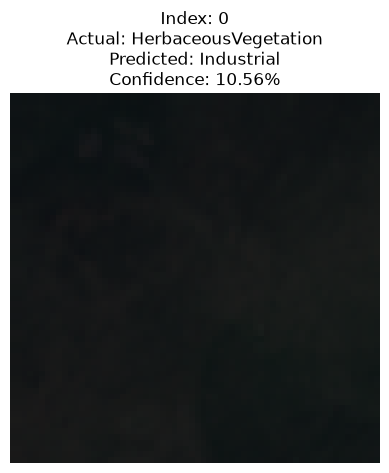

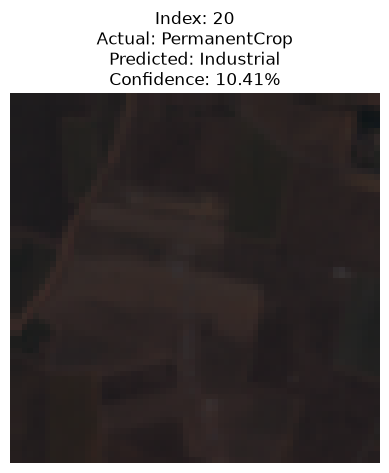

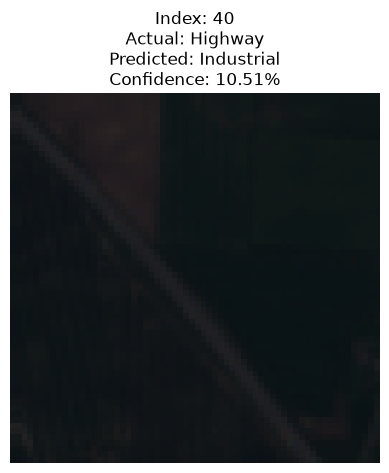

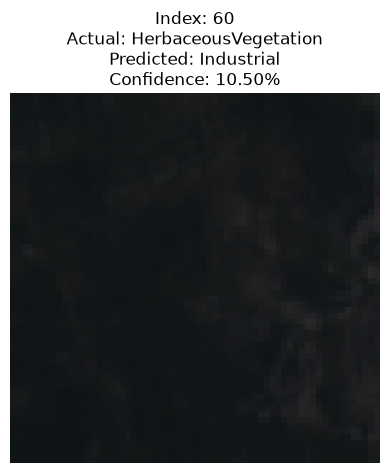

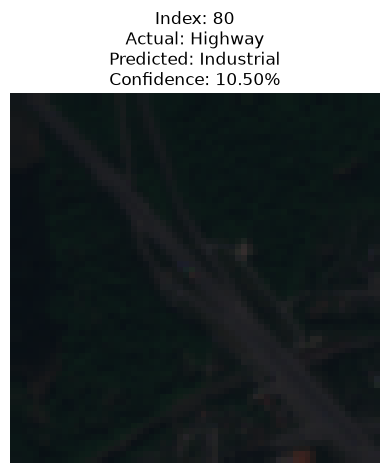

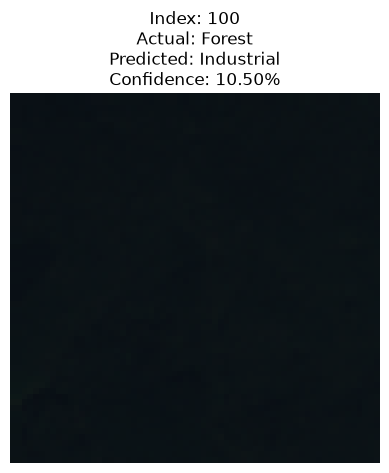

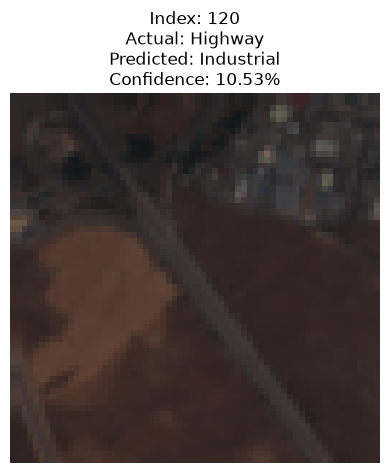

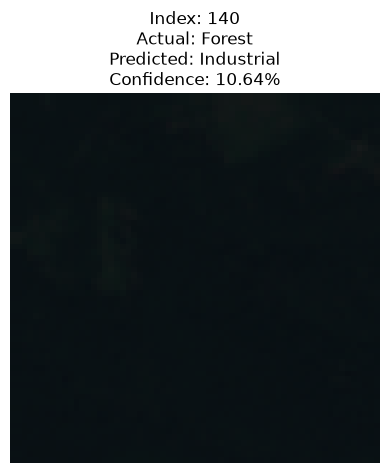

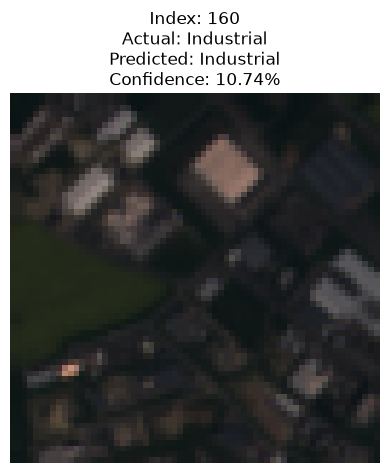

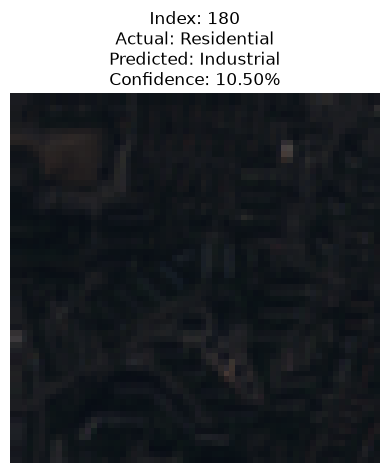

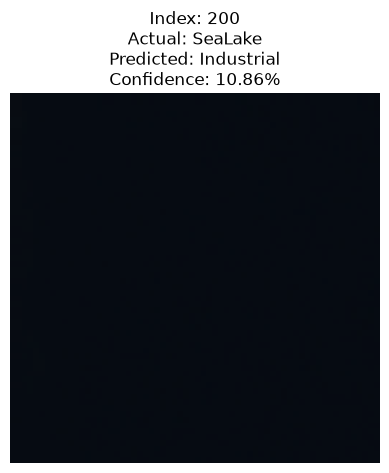

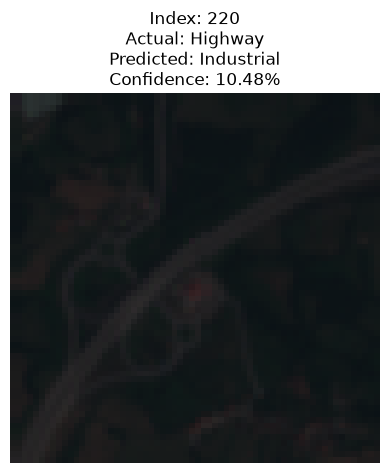

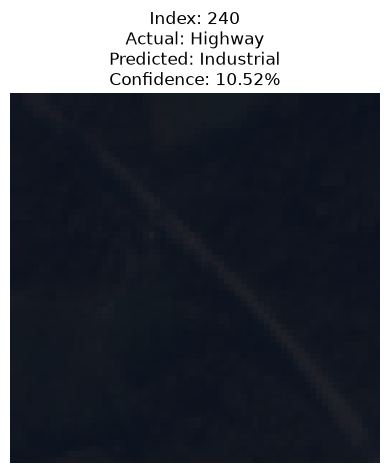

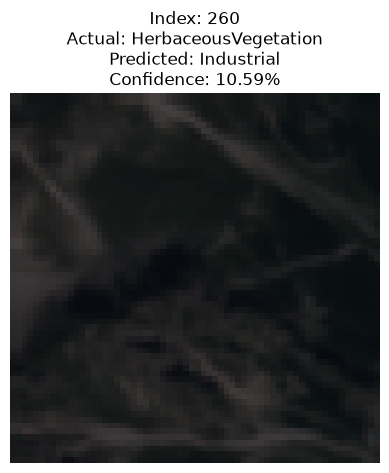

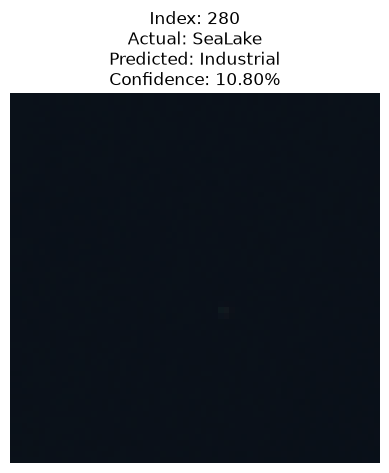

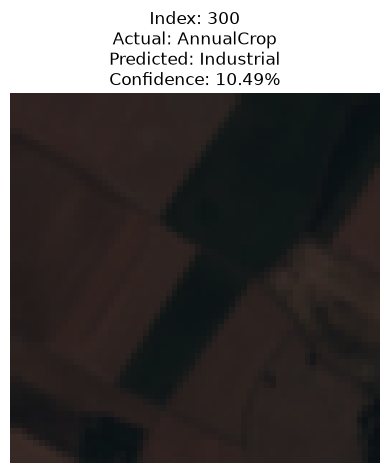

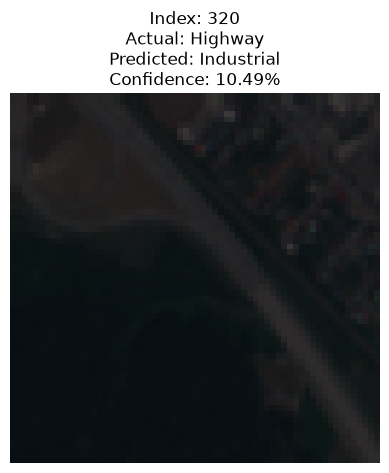

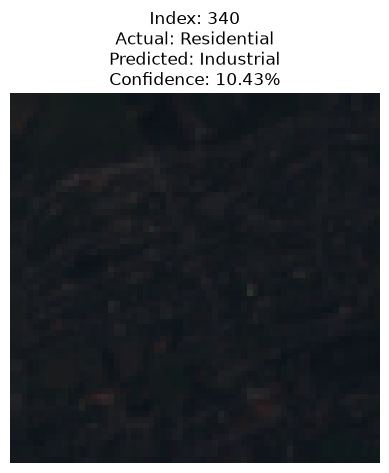

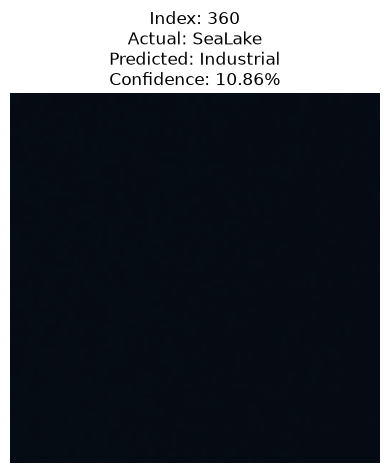

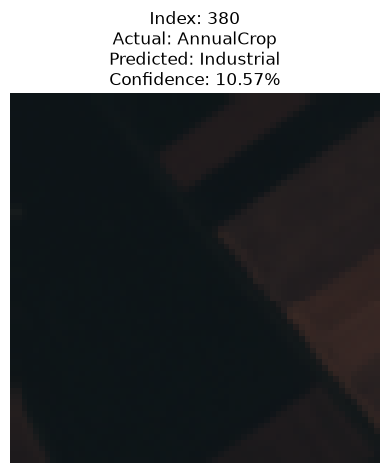

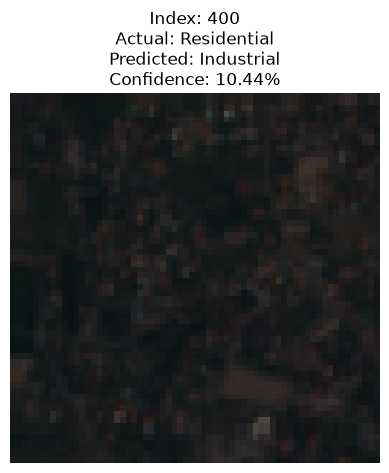

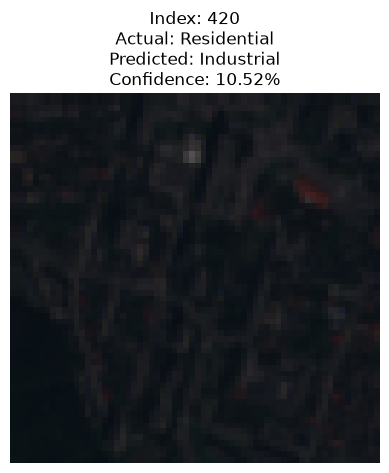

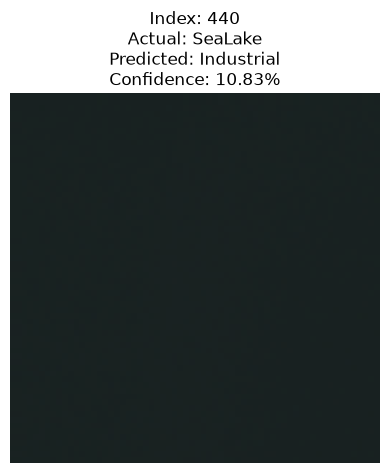

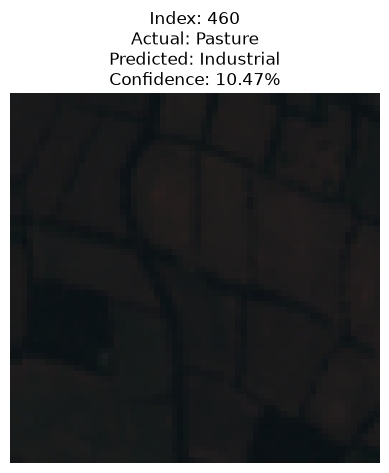

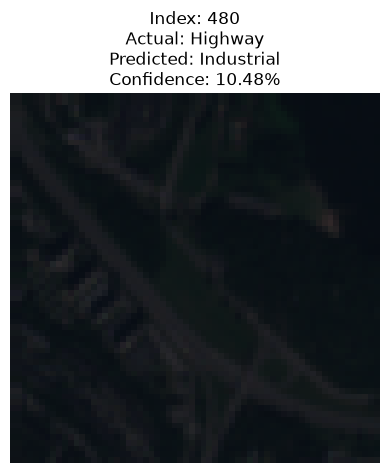

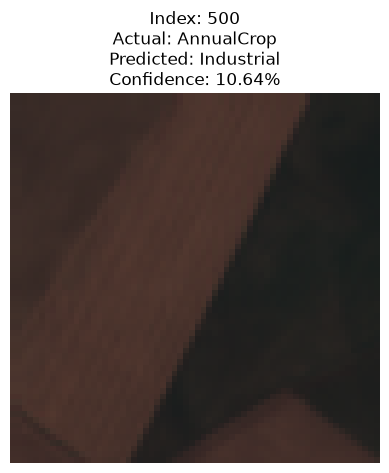

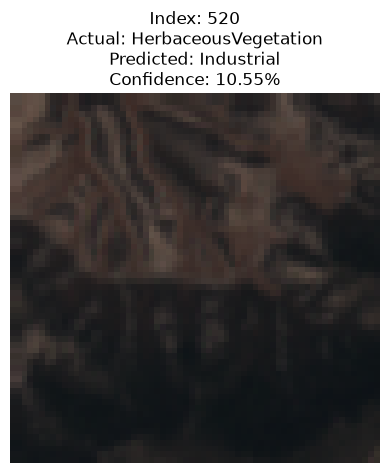

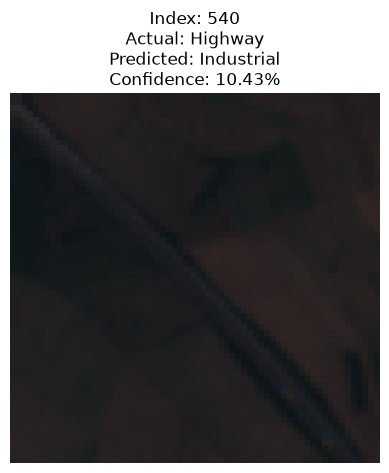

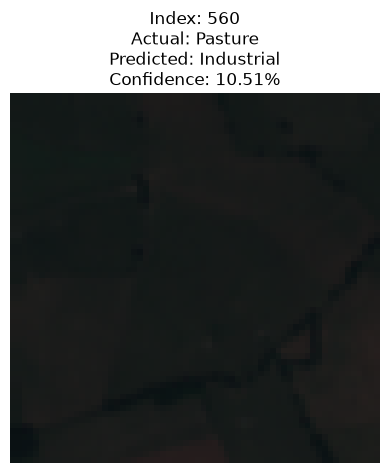

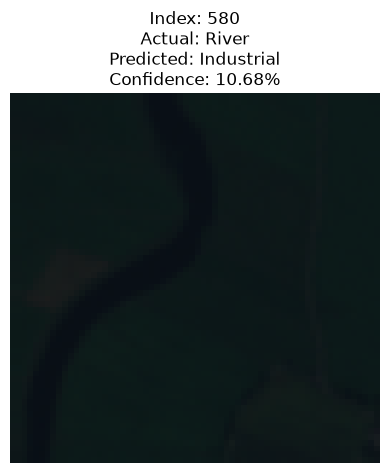

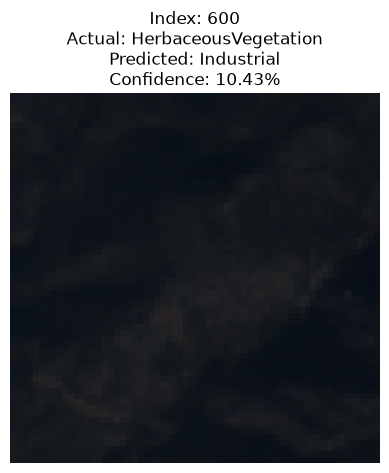

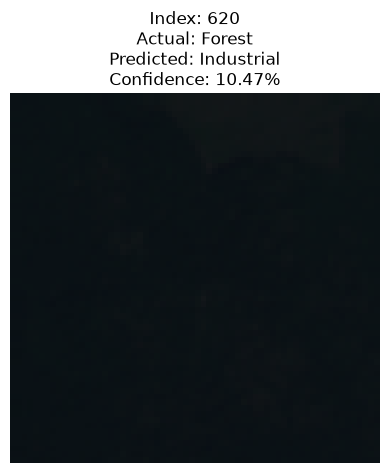

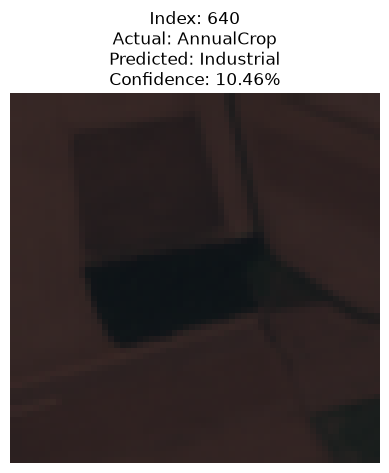

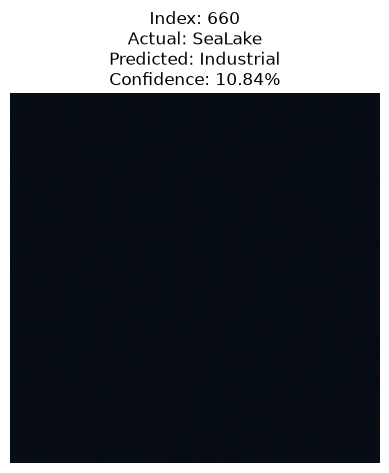

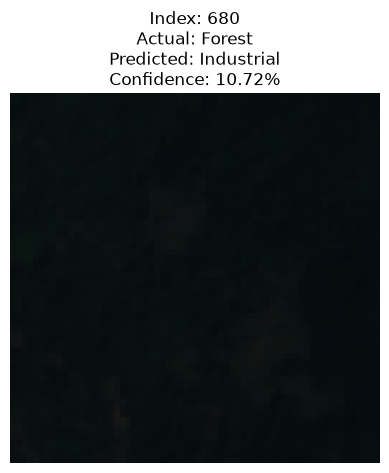

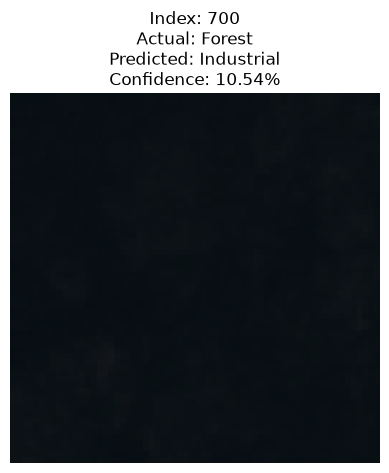

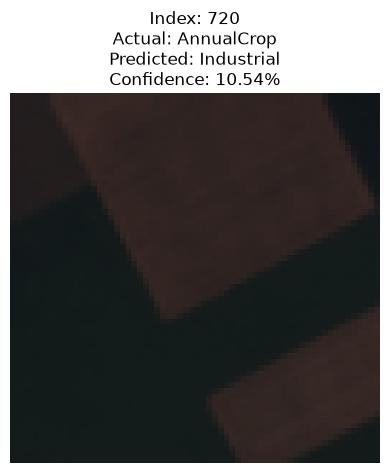

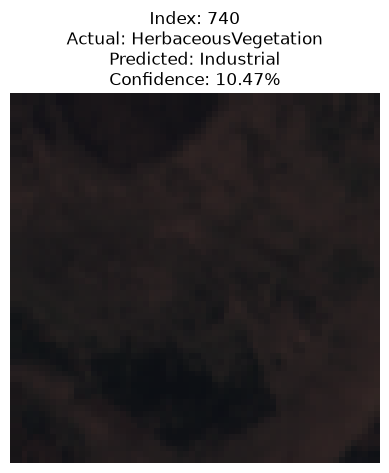

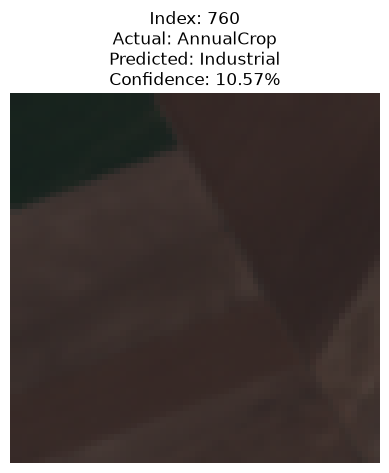

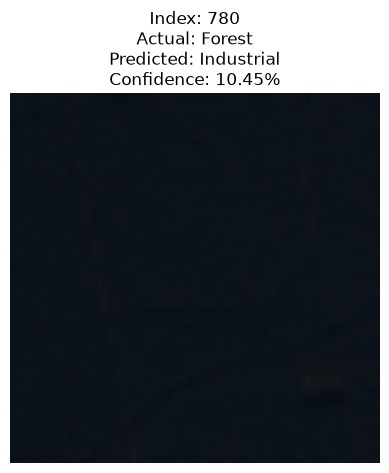

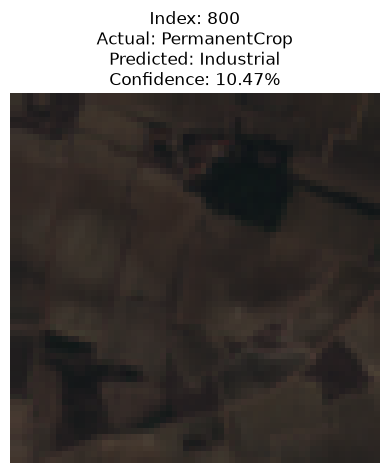

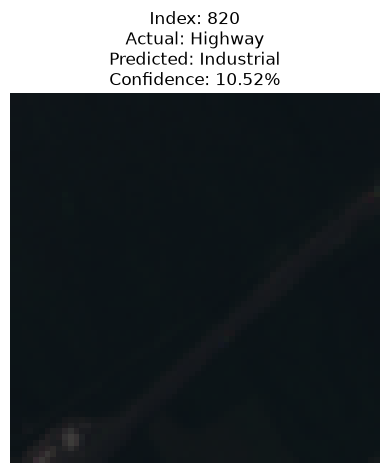

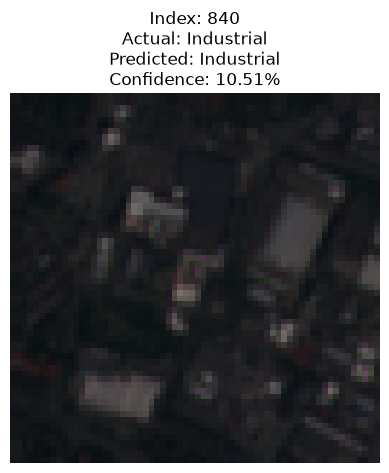

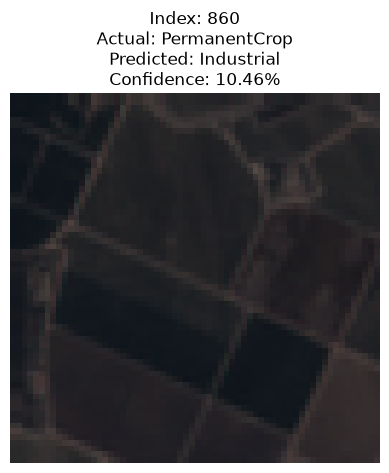

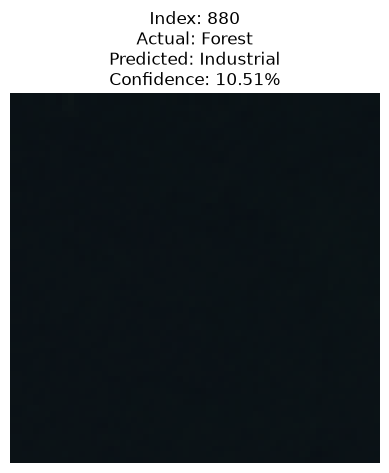

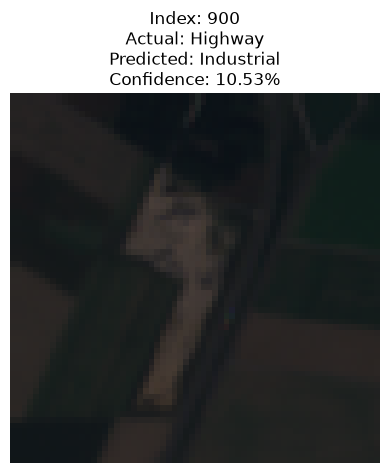

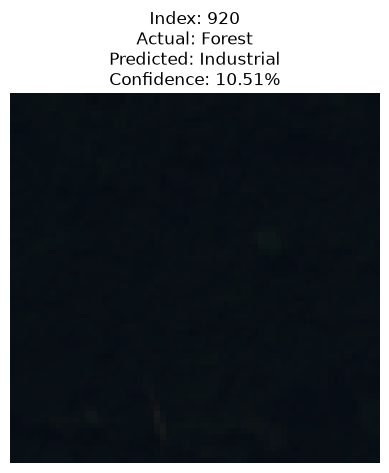

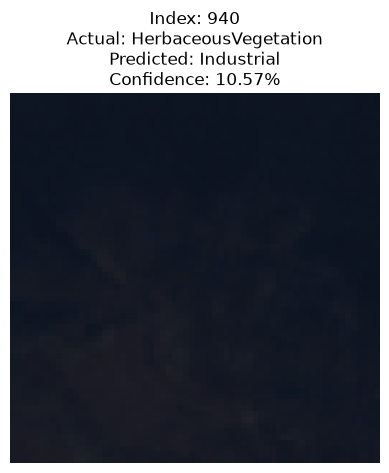

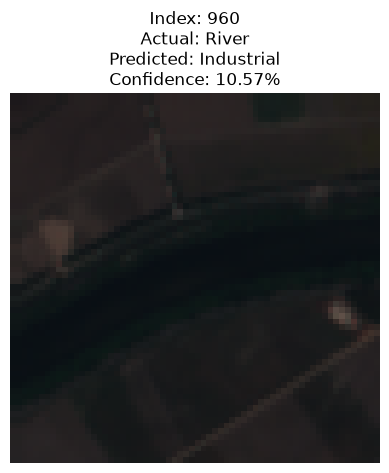

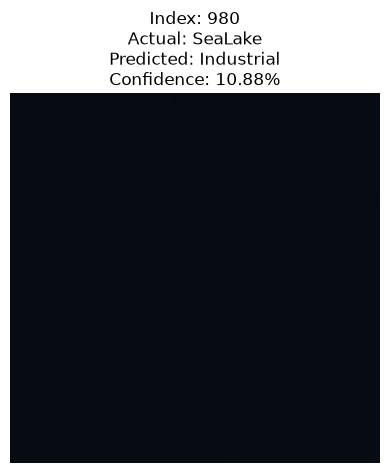

In [30]:
predict_multiple(index_list, delay=3)

In [31]:
## testing on google image ( unseen )
import cv2

test_img_1 = cv2.imread("extra_img/sentinel_image_1.jpeg", )
test_img_2 = cv2.imread("extra_img/test_sentinel.png")

